In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [11]:
models = [
    "Hyb3D2D", "DBDA", "SpectralFormer", "SSAN", "RSSAN",
    "GhostNet", "HiT", "ViT", "LiteDwNet", "EfficientNet"
]

scores_slimbrain = [63.37, 61.83, 60.37, 60.82, 57.61, 56.69, 58.86, 52.00, 10.80, 37.31]
errors_slimbrain = [21.98, 22.61, 22.50, 24.02, 22.77, 22.25, 23.33, 23.23, 15.07, 32.67]

models2 = [
    "Hyb3D2D", "RSSAN", "DBDA", "SSAN", "HiT",
    "SpectralFormer", "LiteDwNet", "GhostNet", "ViT", "EfficientNet"
]

scores_helicoid = [91.13, 90.33, 90.51, 89.05, 88.29, 87.57, 84.73, 84.22, 75.81, 0]
errors_helicoid = [16.06, 14.07, 12.66, 17.99, 15.95, 12.98, 18.82, 18.79, 22.14, 0]

color_map = {
    "conv": "#7AA3D9",
    "hyb": "#ABD19E",
    "att": "#FFE63A",
    "baseline": "#BCAECD"
}

categories_slimbrain = [
    "conv", "hyb", "att", "hyb", "hyb",
    "conv", "hyb", "baseline", "conv", "baseline"
]

categories_helicoid = [
    "conv", "hyb", "hyb", "hyb", "hyb",
    "att", "conv", "conv", "baseline", "baseline"
]

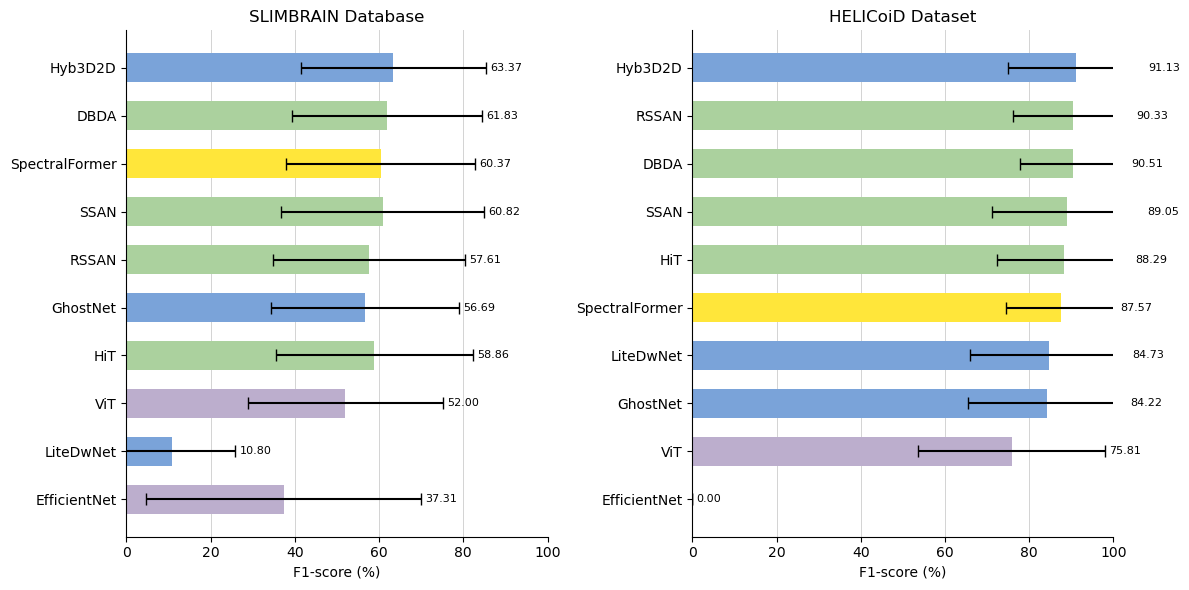

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

# --- SLIMBRAIN ---
y = np.arange(len(models))
colors = [color_map[c] for c in categories_slimbrain]
axes[0].barh(y, scores_slimbrain, xerr=errors_slimbrain, color=colors, height=0.6, capsize=4)
axes[0].set_yticks(y, labels=models)
axes[0].invert_yaxis()
axes[0].set_xlim(0, 100)
axes[0].set_xlabel("F1-score (%)")
axes[0].set_title("SLIMBRAIN Database")

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(axis="x", color="lightgray", linestyle="-", linewidth=0.7)
axes[0].set_axisbelow(True)

for i, (val, err) in enumerate(zip(scores_slimbrain, errors_slimbrain)):
    axes[0].text(val + err + 1, i, f"{val:.2f}", va="center", fontsize=8)

# --- HELICoiD ---
y2 = np.arange(len(models2))
colors2 = [color_map[c] for c in categories_helicoid]
axes[1].barh(y2, scores_helicoid, xerr=errors_helicoid, color=colors2, height=0.6, capsize=4)
axes[1].set_yticks(y2, labels=models2)
axes[1].invert_yaxis()
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("F1-score (%)")
axes[1].set_title("HELICoiD Dataset")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(axis="x", color="lightgray", linestyle="-", linewidth=0.7)
axes[1].set_axisbelow(True)

for i, (val, err) in enumerate(zip(scores_helicoid, errors_helicoid)):
    axes[1].text(val + err + 1, i, f"{val:.2f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("grouped_bar_plot.png", dpi=1200, bbox_inches='tight', transparent=True)
plt.show()
